# Experiment Tracking

(Date - 20/June/2026)

## 0. Necessary imports

In [105]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms, datasets
from going_modular import data_setup, engine
import os
import zipfile
from pathlib import Path
import requests
from torchinfo import summary
from summary_writer import create_writer
from torch.utils.tensorboard import SummaryWriter
from going_modular.utils import save_model
from typing import List
import random
from torch.utils.data import DataLoader
from torchvision.datasets import Food101

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [37]:
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

## 1. Getting the data ready

In [38]:
def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.
    
    Returns:
        pathlib.Path to downloaded data.
    
    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            print(f"[INFO] Downloading {target_file} from {source}...")
            request = requests.get(source)
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip", destination="pizza_steak_sushi")

image_path

[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

## 2. Creating Dataloaders

In [39]:
train_dir = image_path / "train"
test_dir = image_path / "test"

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
automatic_transform = weights.transforms()
print(f"Automatically created transforms:\n{automatic_transform}")

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=str(train_dir),
                                                                               test_dir=str(test_dir),
                                                                               transform=automatic_transform,
                                                                               batch_size=32)

train_dataloader, test_dataloader, class_names

Automatically created transforms:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


(<torch.utils.data.dataloader.DataLoader at 0x1b5dbb34ed0>,
 ['pizza', 'steak', 'sushi'])

## 3. Getting a pretrained model, freezing the base layers and changing the classifier head

In [40]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [41]:
for params in model.features.parameters():
    params.requires_grad = False

set_seeds()

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280,
              out_features=len(class_names),
              bias=True)).to(device)

In [42]:
summary(model, 
        input_size=(32, 3, 224, 224), 
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

## 4. Train model and track results

In [43]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [44]:
set_seeds()
results = engine.train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5,
                device=device,
                writer=SummaryWriter())

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:01<?, ?it/s]


KeyboardInterrupt: 

Note : I got a terrible issue here. I just edited my train function in the engine.py file (from going_modular directory) and ran the above cell... but nothing happened, no runs directory was created... I added a bunch of print statements inside that function but the didn't work too... I realized that I have to restart my VS code to solve the issue. Or use :
```py
import importlib
import going_modular.engine

importlib.reload(going_modular.engine)
```

In [ ]:
results

{'train_loss': [1.088293343782425,
  0.9161567613482475,
  0.8162057995796204,
  0.7460131719708443,
  0.6208599433302879],
 'train_acc': [0.41796875, 0.62890625, 0.703125, 0.73046875, 0.76953125],
 'test_loss': [0.8914491931597391,
  0.8027182022730509,
  0.6786713202794393,
  0.6744383970896403,
  0.6262962420781454],
 'test_acc': [0.6818181818181818,
  0.7443181818181818,
  0.9071969696969697,
  0.8039772727272728,
  0.8560606060606061]}

## 5. View our model's results in TensorBoard

[Follow this guide to view model's result in Tensorboard](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#5-view-our-models-results-in-tensorboard)

<img src="../images/Tensorboard.png">

Install Tensorboard by running this command in your command prompt - `pip install tensorboard`

In powershell run: `tensorboard --logdir="Learning the Basics\34.ipynb\runs"`<br>
_Note_: This is my path, so change accordingly.

Or if you are already in the runs directory, just run : `tensorboard --logdir=runs`

After that go to - `http://localhost:6006/` on your browser.

_Note_: If you don't run your tensorboard (by tensorboard --logdir=runs), then you may encounter an error or nothing at your local host.

You may also need this VS code [Tensorboard guide.](https://code.visualstudio.com/docs/datascience/pytorch-support#_tensorboard-integration)



## Create a helper function to build `SummaryWriter()` instances

(Date - 21/June/2026)

The file - summary_writer.py has been created. Let's test it!

In [ ]:
# Create an example writer
example_writer = create_writer(experiment_name="data_10_percent",
                               model_name="effnetb0",
                               extra="5_epochs"
                               )

[INFO] Created SummaryWriter, saving to: runs\2026-06-23\data_10_percent\effnetb0\5_epochs...


### 6.1 Update the `train()` function to include a `writer` parameter

Updated

## 7. Experiment! Experiment! Experiment!

### 7.1 Getting Data

In [ ]:
# Download 10 percent and 20 percent training data (if necessary)
data_10_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                                     destination="pizza_steak_sushi")

data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

[INFO] data\pizza_steak_sushi directory exists, skipping download.
[INFO] data\pizza_steak_sushi_20_percent directory exists, skipping download.


### 7.2 Setting up the file paths

In [ ]:
train_dir_10_percent = data_10_percent_path / "train"
train_dir_20_percent = data_20_percent_path / "train"

test_dir_10_percent = data_10_percent_path / "test"

print(f"train_dir_10_percent: {train_dir_10_percent}")
print(f"train_dir_20_percent: {train_dir_20_percent}")
print(f"test_dir_10_percent: {test_dir_10_percent}")

train_dir_10_percent: data\pizza_steak_sushi\train
train_dir_20_percent: data\pizza_steak_sushi_20_percent\train
test_dir_10_percent: data\pizza_steak_sushi\test


### 7.3 Transform datasets and creating dataloaders

In [ ]:
# Create a transform to normalize data distribution to be inline with ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], # values per colour channel [red, green, blue]
                                 std=[0.229, 0.224, 0.225]) # values per colour channel [red, green, blue]

# Compose transforms into a pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Resize the images
    transforms.ToTensor(), # 2. Turn the images into tensors with values between 0 & 1
    normalize # 3. Normalize the images so their distributions match the ImageNet dataset 
])

In [ ]:
BATCH_SIZE = 32

# Create 10% training and test DataLoaders
train_dataloader_10_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=str(train_dir_10_percent),
    test_dir=str(test_dir), 
    transform=simple_transform,
    batch_size=BATCH_SIZE
)

# Create 20% training and test data DataLoders
train_dataloader_20_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=str(train_dir_20_percent),
    test_dir=str(test_dir),
    transform=simple_transform,
    batch_size=BATCH_SIZE
)

# Find the number of samples/batches per dataloader (using the same test_dataloader for both experiments)
print(f"Number of batches of size {BATCH_SIZE} in 10 percent training data: {len(train_dataloader_10_percent)}")
print(f"Number of batches of size {BATCH_SIZE} in 20 percent training data: {len(train_dataloader_20_percent)}")
print(f"Number of batches of size {BATCH_SIZE} in testing data: {len(test_dataloader)} (all experiments will use the same test set)")
print(f"Number of classes: {len(class_names)}, class names: {class_names}")

Number of batches of size 32 in 10 percent training data: 8
Number of batches of size 32 in 20 percent training data: 15
Number of batches of size 32 in testing data: 3 (all experiments will use the same test set)
Number of classes: 3, class names: ['pizza', 'steak', 'sushi']


In [ ]:
# 1. Create an instance of EffNetB2 with pretrained weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT # "DEFAULT" means best available weights
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

# # 2. Get a summary of standard EffNetB2 from torchvision.models (uncomment for full output)
summary(model=effnetb2, 
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
) 

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [ ]:
# 3. Get the number of in_features of the EfficientNetB2 classifier layer
print(f"Number of in_features to final layer of EfficientNetB2: {len(effnetb2.classifier.state_dict()['1.weight'][0])}")

Number of in_features to final layer of EfficientNetB2: 1408


### 7.4 Creating functions to build our models

In [ ]:
OUT_FEATURES = len(class_names)

def create_effnetB0():
    model_weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model = torchvision.models.efficientnet_b0(weights=model_weights)

    for params in model.features.parameters():
        params.requires_grad = False

    set_seeds()

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=1280,
                  out_features=OUT_FEATURES,
                  bias=True)).to(device)
    
    model.name = "effnetb0"
    print(f"[INFO] Created new {model.name} model.")
    return model

def create_effnetB2():
    model_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    model = torchvision.models.efficientnet_b2(weights=model_weights)

    for params in model.features.parameters():
        params.requires_grad = False

    set_seeds()

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=1408,
                  out_features=OUT_FEATURES,
                  bias=True))
    
    model.name = "effnetB2"
    print(f"[INFO] Created new {model.name} model")
    return model

In [ ]:
effnetb0 = create_effnetB0()

summary(model=effnetb0,
        input_size = [32, 3, 224, 224],
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"])

[INFO] Created new effnetb0 model.


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

Great!

In [ ]:
effnetb2 = create_effnetB2()

# Get an output summary of the layers in our EffNetB2 feature extractor model (uncomment to view full output)
summary(model=effnetb2, 
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
) 

[INFO] Created new effnetB2 model


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

Great again!

### 7.5 Create experiments and set up training code

In [ ]:
num_epochs = [5, 10]

models = ["effnetb0", "effnetb2"]

train_dataloaders = {"data_10_percent" : train_dataloader_10_percent,
                     "data_20_percent" : train_dataloader_20_percent}

In [ ]:
# %%time
# set_seeds()
# experiment_number = 0
# for dataloader_name, dataloader in train_dataloaders.items():
#     for epochs in num_epochs:
#         for model_name in models:
#             experiment_number += 1
#             print(f"[INFO] Experiment No. {experiment_number}")
#             print(f"[INFO] Model: {model_name}")
#             print(f"[INFO] Dataloader : {dataloader_name}")
#             print(f"[INFO] Number of epochs : {epochs}")

#             if model_name == "effnetb0":
#                 model = create_effnetB0()
#             else:
#                 model = create_effnetB2()

#             loss = nn.CrossEntropyLoss()
#             optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

#             engine.train(model=model,
#             train_dataloader=dataloader,
#             test_dataloader = test_dataloader,
#             epochs=epochs,
#             optimizer=optimizer,
#             loss_fn=loss_fn,
#             device=device,
#             writer=create_writer(experiment_name=dataloader_name,
#                                        model_name=model_name,
#                                        extra=f"{epochs}_epochs")
#             )
#             save_filepath = f"07_{model_name}_{dataloader_name}_{epochs}_epochs.pth"
#             save_model(model=model,
#                        target_dir="models",
#                        model_name=save_filepath)
#             print("-"*50 + "\n")



## 8. View Experiments in tensorboard

<img src = "../images/Tensorboard(2).png">
Experiment 7 has shown the best model (i.e. Efficient net B0 - 20 percent data - 10 epochs)

Done! (I haven't shown everything)


## 9. Loading in the best model

In [ ]:
# Setup the best model filepath
best_model_path = "models/07_effnetb0_data_20_percent_10_epochs.pth"

# Instantiate a new instance of EffNetB2 (to load the saved state_dict() to)
best_model = create_effnetB0()

# Load the saved best model state_dict()
best_model.load_state_dict(torch.load(best_model_path))

[INFO] Created new effnetb0 model.


<All keys matched successfully>

In [ ]:
# Check the model file size
# Get the model size in bytes then convert to megabytes
effnetb2_model_size = Path(best_model_path).stat().st_size // (1024*1024)
print(f"EfficientNetB2 feature extractor model size: {effnetb2_model_size} MB")

EfficientNetB2 feature extractor model size: 15 MB


In [ ]:
from typing import List, Tuple

from PIL import Image

# 1. Take in a trained model, class names, image path, image size, a transform and target device
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str, 
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    
    
    # 2. Open image
    img = Image.open(image_path)

    # 3. Create transformation for image (if one doesn't exist)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    ### Predict on image ### 

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
      # 6. Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
      transformed_image = image_transform(img).unsqueeze(dim=0)

      # 7. Make a prediction on image with an extra dimension and send it to the target device
      target_image_pred = model(transformed_image.to(device))

    # 8. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 9. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 10. Plot image with predicted label and probability 
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);

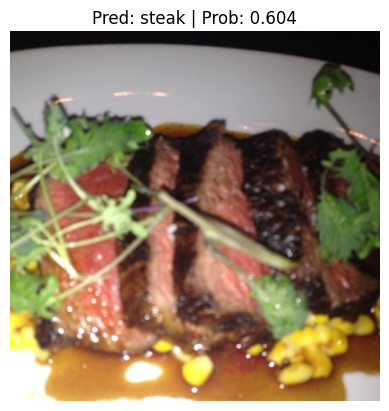

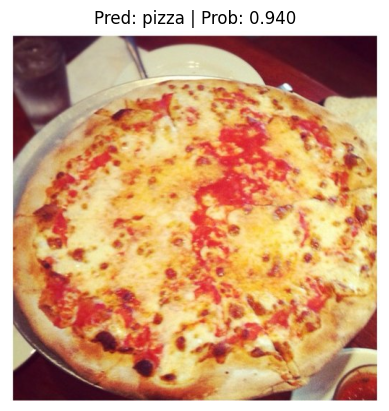

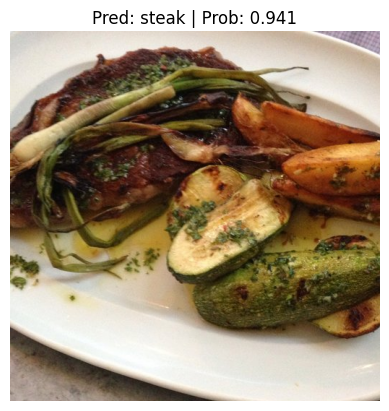

In [ ]:
num_images_to_plot = 3
test_image_path_list = list(Path(data_20_percent_path / "test").glob("*/*.jpg")) # get all test image paths from 20% dataset
test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=num_images_to_plot) # randomly select k number of images

# Iterate through random test image paths, make predictions on them and plot them
for image_path in test_image_path_sample:
    pred_and_plot_image(model=best_model,
                        image_path=str(image_path),
                        class_names=class_names)

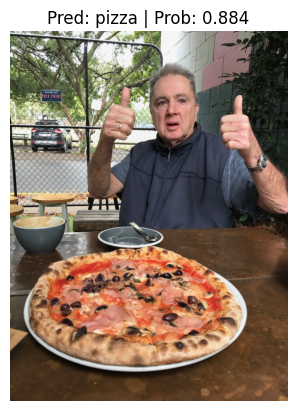

In [ ]:
pred_and_plot_image(model=best_model,
                    image_path="../images/DanielDad.jpeg",
                    class_names=class_names)

YEAHHHHHHHHHHHHHHHHHHHHH!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# Exercise

(Date - 2/June/2026)

1. Pick a larger model from torchvision.models to add to the list of experiments (for example, EffNetB3 or higher).
* How does it perform compared to our existing models?

In [33]:
dummy_weights = torchvision.models.EfficientNet_B3_Weights.DEFAULT
dummy_model = torchvision.models.efficientnet_b3(weights=dummy_weights)

summary(model=dummy_model,
        row_settings=["var_names"],
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1536, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 40, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 40, 112, 112]   1,080                True
│    │    └─BatchNorm2d (1)                                  [32, 40, 112, 112]   [32, 40, 112, 112]   80                   True
│    │    └─SiLU (2)                                         [32, 40, 112, 112]   [32, 40, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 40, 112, 112]   [32, 24, 112

In [34]:
def create_effnetB3():
    model_weights = torchvision.models.EfficientNet_B3_Weights.DEFAULT
    model = torchvision.models.efficientnet_b3(weights=model_weights)

    for params in model.features.parameters():
        params.requires_grad = False

    set_seeds()

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=1536,
                  out_features=OUT_FEATURES,
                  bias=True))
    
    model.name = "effnetB3"
    print(f"[INFO] Created new {model.name} model")
    return model

In [35]:
effnet_b3 = create_effnetB3()

summary(model=effnet_b3,
        row_settings=["var_names"],
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20)

[INFO] Created new effnetB3 model


KeyboardInterrupt: 

In [ ]:
num_epochs = [5, 10]

train_dataloaders = {"data_10_percent" : train_dataloader_10_percent,
                     "data_20_percent" : train_dataloader_20_percent}

In [ ]:
# experiment_no = 0

# for epochs in num_epochs:
#     for dataloader_name, dataloader in train_dataloaders.items():
#         experiment_no += 1
#         print(f"Experiment no. {experiment_no}")
#         print(f"Number of epochs : {epochs}")
#         print(f"train_dataloader : {dataloader_name}")
        
#         model = create_effnetB3()
#         model.name = "effnet_b3"

#         loss = nn.CrossEntropyLoss()
#         optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

#         engine.train(model=model,
#         train_dataloader=dataloader,
#         test_dataloader = test_dataloader,
#         epochs=epochs,
#         optimizer=optimizer,
#         loss_fn=loss_fn,
#         device=device,
#         writer=create_writer(experiment_name=dataloader_name,
#                                     model_name=model.name,
#                                     extra=f"{epochs}_epochs")
#         )
#         save_filepath = f"07_{model.name}_{dataloader_name}_{epochs}_epochs.pth"
#         save_model(model=model,
#                     target_dir="models",
#                     model_name=save_filepath)
#         print("-"*50 + "\n")
        
        

Experiment no. 1
Number of epochs : 5
train_dataloader : data_10_percent
[INFO] Created new effnetB2 model
[INFO] Created SummaryWriter, saving to: runs\2026-06-23\data_10_percent\effnet_b3\5_epochs...


 20%|██        | 1/5 [00:31<02:05, 31.44s/it]

Epoch: 1 | train_loss: 1.0856 | train_acc: 0.4102 | test_loss: 1.0322 | test_acc: 0.5786


 40%|████      | 2/5 [01:02<01:33, 31.10s/it]

Epoch: 2 | train_loss: 0.8782 | train_acc: 0.8047 | test_loss: 0.9119 | test_acc: 0.6525


...

Epoch: 8 | train_loss: 0.3343 | train_acc: 0.9229 | test_loss: 0.4184 | test_acc: 0.8655


 90%|█████████ | 9/10 [08:28<00:56, 56.60s/it]

Epoch: 9 | train_loss: 0.3164 | train_acc: 0.9250 | test_loss: 0.4129 | test_acc: 0.8456


100%|██████████| 10/10 [09:25<00:00, 56.55s/it]

Epoch: 10 | train_loss: 0.3136 | train_acc: 0.9062 | test_loss: 0.4094 | test_acc: 0.8352
[INFO] Saving model to: models\07_effnet_b3_data_20_percent_10_epochs.pth
--------------------------------------------------



(Date - 23/June/2026)

2. Introduce data augmentation to the list of experiments using the 20% pizza, steak, sushi training and test datasets, does this change anything?
* For example, you could have one training DataLoader that uses data augmentation (e.g. train_dataloader_20_percent_aug and train_dataloader_20_percent_no_aug) and then compare the results of two of the same model types training on these two DataLoaders.
* Note: You may need to alter the create_dataloaders() function to be able to take a transform for the training data and the testing data (because you don't need to perform data augmentation on the test data). See 04. PyTorch Custom Datasets section 6 for examples of using data augmentation or the script below for an example:

In [46]:
NUM_WORKERS = 0

def create_dataloaders(
    train_dir: str, 
    test_dir: str, 
    train_transform: transforms.Compose, 
    test_transform: transforms.Compose,
    batch_size: int, 
    num_workers: int=NUM_WORKERS
):
  """Creates training and testing DataLoaders.

  Takes in a training directory and testing directory path and turns
  them into PyTorch Datasets and then into PyTorch DataLoaders.

  Args:
    train_dir: Path to training directory.
    test_dir: Path to testing directory.
    transform: torchvision transforms to perform on training and testing data.
    batch_size: Number of samples per batch in each of the DataLoaders.
    num_workers: An integer for number of workers per DataLoader.

  Returns:
    A tuple of (train_dataloader, test_dataloader, class_names).
    Where class_names is a list of the target classes.
    Example usage:
      train_dataloader, test_dataloader, class_names = \
        = create_dataloaders(train_dir=path/to/train_dir,
                             test_dir=path/to/test_dir,
                             transform=some_transform,
                             batch_size=32,
                             num_workers=4)
  """
  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_dir, transform=train_transform)
  test_data = datasets.ImageFolder(test_dir, transform=test_transform)

  # Get class names
  class_names = train_data.classes

  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,

  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False, # don't need to shuffle test data
      num_workers=num_workers,

  )

  return train_dataloader, test_dataloader, class_names

I have alter the data_setup.py... But because of some VS code problems, I will have to restart it in order to make that data_setup.py file work... I mean if I try to use its create_dataloader function, then the changes will be avoided, and I am required to restart everything. But because I don't wanna restart, I have put the create_dataloader function right here.

In [88]:
train_transform_data_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    normalize
])

# Helper function to view images in a DataLoader (works with data augmentation transforms or not) 
def view_dataloader_images(dataloader, n=10):
    if n > 10:
        print(f"Having n higher than 10 will create messy plots, lowering to 10.")
        n = 10
    imgs, labels = next(iter(dataloader))
    plt.figure(figsize=(16, 8))
    for i in range(n):
        # Min max scale the image for display purposes
        targ_image = imgs[i]
        sample_min, sample_max = targ_image.min(), targ_image.max()
        sample_scaled = (targ_image - sample_min)/(sample_max - sample_min)

        # Plot images with appropriate axes information
        plt.subplot(1, 10, i+1)
        plt.imshow(sample_scaled.permute(1, 2, 0)) # resize for Matplotlib requirements
        plt.title(class_names[labels[i]])
        plt.axis(False)

In [89]:
train_dataloader_20_percent_aug, test_dataloader_10_percent_no_aug, class_names = create_dataloaders(train_dir=str(train_dir_20_percent),
                                                                                                  test_dir=str(test_dir_10_percent),
                                                                                                  train_transform=train_transform_data_aug,
                                                                                                  test_transform=None,
                                                                                                  batch_size=32)

train_dataloader_20_percent_aug, test_dataloader_10_percent_no_aug, class_names
                                                                                                  

(<torch.utils.data.dataloader.DataLoader at 0x1b5e1174e90>,
 ['pizza', 'steak', 'sushi'])

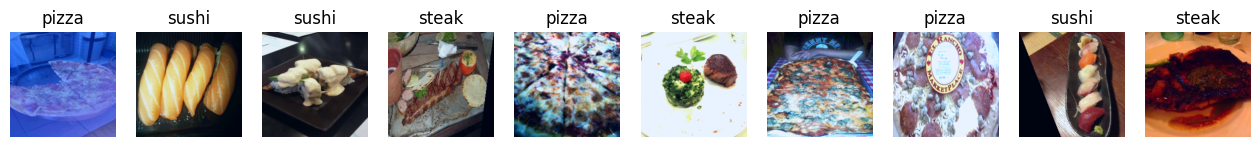

In [101]:
view_dataloader_images(train_dataloader_20_percent_aug, n=10)

In [103]:
num_epochs = [5, 10]

train_dataloaders = {"data_20_percent_no_aug" : train_dataloader_20_percent,
                     "data_20_percent_aug" : train_dataloader_20_percent_aug}

In [104]:
experiment_no = 0

for epochs in num_epochs:
    for dataloader_name, dataloader in train_dataloaders.items():
        experiment_no += 1
        print(f"Experiment no. {experiment_no}")
        print(f"Number of epochs : {epochs}")
        print(f"train_dataloader : {dataloader_name}")
        
        model = create_effnetB3()
        model.name = "effnet_b3"

        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

        engine.train(model=model,
        train_dataloader=dataloader,
        test_dataloader = test_dataloader,
        epochs=epochs,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        writer=create_writer(experiment_name=dataloader_name,
                                    model_name=model.name,
                                    extra=f"{epochs}_epochs")
        )
        save_filepath = f"07_{model.name}_{dataloader_name}_{epochs}_epochs.pth"
        save_model(model=model,
                    target_dir="models",
                    model_name=save_filepath)
        print("-"*50 + "\n")
        
        

Experiment no. 1
Number of epochs : 5
train_dataloader : data_20_percent_no_aug
[INFO] Created new effnetB3 model
[INFO] Created SummaryWriter, saving to: runs\2026-06-23\data_20_percent_no_aug\effnet_b3\5_epochs...


 20%|██        | 1/5 [00:56<03:44, 56.16s/it]

Epoch: 1 | train_loss: 0.9737 | train_acc: 0.5875 | test_loss: 0.8488 | test_acc: 0.7339


 40%|████      | 2/5 [01:49<02:43, 54.35s/it]

Epoch: 2 | train_loss: 0.7415 | train_acc: 0.8125 | test_loss: 0.6064 | test_acc: 0.8968


...

Epoch: 8 | train_loss: 0.4251 | train_acc: 0.8688 | test_loss: 0.3490 | test_acc: 0.9176


 90%|█████████ | 9/10 [09:08<01:00, 60.81s/it]

Epoch: 9 | train_loss: 0.3821 | train_acc: 0.8771 | test_loss: 0.3645 | test_acc: 0.9176


100%|██████████| 10/10 [10:08<00:00, 60.83s/it]

Epoch: 10 | train_loss: 0.4090 | train_acc: 0.8396 | test_loss: 0.2929 | test_acc: 0.9176
[INFO] Saving model to: models\07_effnet_b3_data_20_percent_aug_10_epochs.pth
--------------------------------------------------



3. Scale up the dataset to turn FoodVision Mini into FoodVision Big using the entire Food101 dataset from torchvision.models
* You could take the best performing model from your various experiments or even the EffNetB2 feature extractor we created in this notebook and see how it goes fitting for 5 epochs on all of Food101.
* If you try more than one model, it would be good to have the model's results tracked.
* If you load the Food101 dataset from torchvision.models, you'll have to create PyTorch DataLoaders to use it in training.
* Note: Due to the larger amount of data in Food101 compared to our pizza, steak, sushi dataset, this model will take longer to train.

In [108]:
train_data = Food101(
    root="data/Food101",
    split="train",
    download=True
)

test_data = Food101(
    root="data/Food101",
    split="test",
    download=True
)

# Food101_train_dir = 
# Food101_test_dir = 

  0%|          | 5.14M/5.00G [00:05<1:29:38, 928kB/s] 


KeyboardInterrupt: 

In [ ]:
Food101_train_dataloader = create_dataloaders(train_dir=Food101_train_dir,
                                              test_dir=Food101_test_dir,
                                              train_transform=train_transform_data_aug,
                                              test_transform=None,
                                              batch_size=32)

Sorry I can't do this because the dataset is of 5 GB and my wifi connection is poor.